# Figures for Meeting 5 of the Physics 225 Notebook

Focuses on Vectors

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 

plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

fsize = 9
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": fsize,
    "axes.titlesize": fsize,
    "axes.labelsize": fsize,
    "xtick.labelsize": fsize,
    "ytick.labelsize": fsize,
    "legend.fontsize": fsize,
})

def map_arrow(pt1, pt2, pt3, maplabel,
              label1gap=0.3, label2gap=0.3, mapgap=0.3,
              lw=0.75, head_width=0.05, head_length=0.1):

    def circle_from_3pts(p1, p2, p3):

        cross = ((p2[0] - p1[0]) * (p3[1] - p1[1])
               - (p2[1] - p1[1]) * (p3[0] - p1[0]))

        if abs(cross) < 1e-12:
            return None, None

        x1, y1 = p1
        x2, y2 = p2
        x3, y3 = p3

        D = 2 * (
            x1 * (y2 - y3)
            + x2 * (y3 - y1)
            + x3 * (y1 - y2)
        )

        Ux = (
            (x1**2 + y1**2) * (y2 - y3)
            + (x2**2 + y2**2) * (y3 - y1)
            + (x3**2 + y3**2) * (y1 - y2)
        ) / D

        Uy = (
            (x1**2 + y1**2) * (x3 - x2)
            + (x2**2 + y2**2) * (x1 - x3)
            + (x3**2 + y3**2) * (x2 - x1)
        ) / D

        center = np.array([Ux, Uy])
        radius = np.linalg.norm(p1 - center)

        return center, radius

    center, radius = circle_from_3pts(pt1, pt2, pt3)

    # ------------------------------------------------------------
    # Collinear case
    # ------------------------------------------------------------
    if center is None:

        v1 = pt2 - pt1
        v1 /= np.linalg.norm(v1)

        v2 = pt3 - pt2
        v2 /= np.linalg.norm(v2)

        start1 = pt1 + label1gap * v1
        end1   = pt2 - mapgap * v1

        start2 = pt2 + mapgap * v2
        end2   = pt3 - label2gap * v2

        plt.plot(
            [start1[0], end1[0]],
            [start1[1], end1[1]],
            'k-', lw=lw
        )

        plt.plot(
            [start2[0], end2[0]],
            [start2[1], end2[1]],
            'k-', lw=lw
        )

        for start, end in [(start1, end1), (start2, end2)]:
            dx = end[0] - start[0]
            dy = end[1] - start[1]

            plt.arrow(
                start[0], start[1],
                dx, dy,
                head_width=head_width,
                head_length=head_length,
                fc='k',
                ec='k',
                length_includes_head=True
            )

        plt.annotate(
            maplabel,
            pt2,
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold'
        )
        return

    # ------------------------------------------------------------
    # Angles
    # ------------------------------------------------------------
    def angle(pt):
        return np.arctan2(
            pt[1] - center[1],
            pt[0] - center[0]
        )

    theta1 = angle(pt1)
    theta2 = angle(pt2)
    theta3 = angle(pt3)

    # ------------------------------------------------------------
    # Positive CCW angular distance
    # ------------------------------------------------------------
    def ccw_dist(a, b):
        return (b - a) % (2 * np.pi)

    d12 = ccw_dist(theta1, theta2)
    d13 = ccw_dist(theta1, theta3)

    # ------------------------------------------------------------
    # Determine which pt1 -> pt3 arc contains pt2
    # ------------------------------------------------------------
    if d12 < d13:

        t1 = theta1
        t2 = theta1 + d12
        t3 = theta1 + d13

        direction = 1

    else:

        t1 = theta1
        t2 = theta1 - ccw_dist(theta2, theta1)
        t3 = theta1 - ccw_dist(theta3, theta1)

        direction = -1

    # ------------------------------------------------------------
    # Convert requested linear gaps to angular gaps
    # ------------------------------------------------------------
    gap1 = label1gap / radius
    gap2 = label2gap / radius
    gapm = mapgap / radius

    # ------------------------------------------------------------
    # Split the selected arc into two pieces
    # ------------------------------------------------------------
    if direction == 1:

        arc1_start = t1 + gap1
        arc1_end   = t2 - gapm

        arc2_start = t2 + gapm
        arc2_end   = t3 - gap2

    else:

        arc1_start = t1 - gap1
        arc1_end   = t2 + gapm

        arc2_start = t2 - gapm
        arc2_end   = t3 + gap2

    # ------------------------------------------------------------
    # Generate circular arc
    # ------------------------------------------------------------
    def make_arc(a, b, n=200):

        theta = np.linspace(a, b, n)

        x = center[0] + radius * np.cos(theta)
        y = center[1] + radius * np.sin(theta)

        return x, y

    x1, y1 = make_arc(arc1_start, arc1_end)
    x2, y2 = make_arc(arc2_start, arc2_end)

    # ------------------------------------------------------------
    # Draw arcs
    # ------------------------------------------------------------
    plt.plot(x1, y1, 'k-', lw=lw)
    plt.plot(x2, y2, 'k-', lw=lw)

    # ------------------------------------------------------------
    # Actual plt.arrow at the END of each arc
    # ------------------------------------------------------------
    def add_arrow(x, y):

        i = 10

        x0 = x[-i]
        y0 = y[-i]

        x1 = x[-1]
        y1 = y[-1]

        dx = x1 - x0
        dy = y1 - y0

        plt.arrow(
            x0,
            y0,
            dx,
            dy,
            head_width=head_width,
            head_length=head_length,
            fc='k',
            ec='k',
            length_includes_head=True,
            zorder=5
        )

    add_arrow(x1, y1)
    add_arrow(x2, y2)

    # ------------------------------------------------------------
    # Label at pt2
    # ------------------------------------------------------------
    plt.annotate(
        maplabel,
        pt2,
        ha='center',
        va='center',
        fontweight='bold'
    )


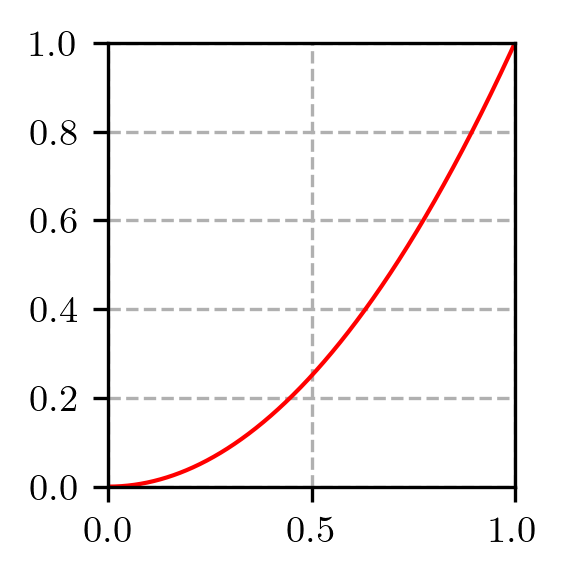

In [2]:
figname = r'..\images\fig1.pdf'

x = np.linspace(0,1,1000)
y = x**2 

plt.figure(figsize = (2,2),dpi = 300)
plt.plot(x,y,'r-', lw = 1)
plt.xlim(x.min(),x.max())
plt.ylim(0,1)
plt.grid(linestyle = '--')
plt.tight_layout()
plt.savefig(figname)
plt.show()

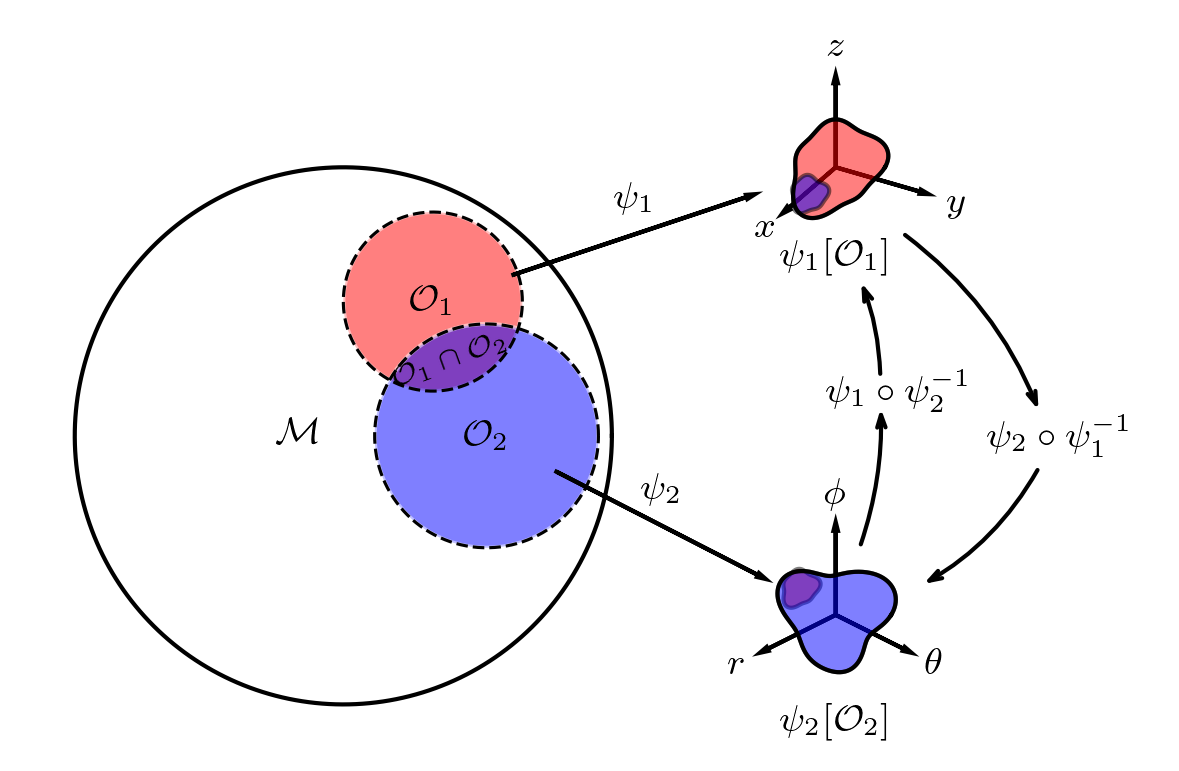

In [ ]:
fig3 = r'..\images\manifold_example.pdf'
from matplotlib.patches import FancyArrowPatch
plt.figure(figsize=(4, 3), dpi=300)
plt.gca().set_aspect('equal')


# =========================================================
# Manifold M
# =========================================================

theta = np.linspace(0, 2*np.pi, 500)

radius = 3

manifold = np.array([
    radius * np.cos(theta),
    radius * np.sin(theta)
])

plt.plot(
    manifold[0],
    manifold[1],
    'k-',
    lw=1
)

plt.annotate(
    r'$\mathcal{M}$',
    [-0.5, 0],
    ha='center',
    va='center'
)


# ---------------------------------------------------------
# Blob function
# ---------------------------------------------------------

def blob(theta, scale=1, phase=0, a = 0.15, b = 0.10, c = 0.07):
    r = scale * (
        1
        + a * np.sin(2*theta + phase)
        + b * np.cos(3*theta - phase)
        + c * np.sin(5*theta + 0.5*phase)
    )

    return r*np.cos(theta), r*np.sin(theta)
# =========================================================
# Manifold O_1
# =========================================================

radius = 1
posM1 = [1,1.5]
manifoldO1 = np.array([
    radius * np.cos(theta) + posM1[0],
    radius * np.sin(theta) + posM1[1]
])

plt.fill(
    manifoldO1[0],
    manifoldO1[1],
    facecolor='red',
    alpha = 0.5,
    edgecolor='w',
    linewidth=1
)

plt.plot(
    manifoldO1[0],
    manifoldO1[1],
    'k--',
    lw=0.75
)

plt.annotate(
    r'$\mathcal{O}_1$',
    posM1,
    ha='center',
    va='center'
)


# =========================================================
# Manifold O_2
# =========================================================

radius = 1.25
posM2 = [1.6,0]
manifoldO2 = np.array([
    radius * np.cos(theta) + posM2[0],
    radius * np.sin(theta) + posM2[1]
])

plt.fill(
    manifoldO2[0],
    manifoldO2[1],
    facecolor='blue',
    alpha = 0.5,
    edgecolor='w',
    linewidth=1
)
plt.plot(
    manifoldO2[0],
    manifoldO2[1],
    'k--',
    lw=0.75
)

plt.annotate(
    r'$\mathcal{O}_2$',
    posM2,
    ha='center',
    va='center'
)


# =========================================================
# Coordinate axes
# =========================================================

def draw_axis(
    pos,
    axisname=None,
    azimuth=0,
    elevation=30,
    axislen=1,
    labeldist=1.3
):

    # Degrees -> radians
    azimuth = np.deg2rad(azimuth)
    elevation = np.deg2rad(elevation)

    # Original 3D Cartesian basis
    axes3d = np.array([
        [1, 0, 0],   # x
        [0, 1, 0],   # y
        [0, 0, 1]    # z
    ])

    # Orthographic projection
    P = np.array([
        [np.cos(azimuth),
         np.sin(azimuth) * np.sin(elevation)],

        [-np.sin(azimuth),
         np.cos(azimuth) * np.sin(elevation)],

        [0,
         np.cos(elevation)]
    ])

    # Project 3D basis -> 2D
    axes2d = axes3d @ P

    # Labels
    if axisname is None:
        labels = [
            r'$\mathbf{1}$',
            r'$\mathbf{2}$',
            r'$\mathbf{n}$'
        ]
    else:
        labels = axisname

    for ax, label in zip(axes2d, labels):

        plt.arrow(
            pos[0],
            pos[1],
            axislen * ax[0],
            axislen * ax[1],
            color='k',
            linewidth=1,
            head_width=0.05,
            head_length=0.1,
            length_includes_head=True
        )

        plt.annotate(
            label,
            [
                pos[0] + labeldist * axislen * ax[0],
                pos[1] + labeldist * axislen * ax[1]
            ],
            ha='center',
            va='center'
        )

axis1pos = [5.5,3]
draw_axis(
    axis1pos,
    axisname=[r'$x$', r'$y$', r'$z$'],
    azimuth=-120,
    elevation=30,
    axislen=1.2
)
axis2pos = [5.5,-2]
draw_axis(
    axis2pos,
    axisname=[r'$r$', r'$\theta$', r'$\phi$'],
    azimuth=-135,
    elevation=30,
    axislen=1.2
)
# ================================================
# Images
# ================================================

x, y = blob(theta, 0.5,0)
plt.fill(
    x + axis1pos[0], y + axis1pos[1],
    facecolor='red',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)
plt.plot(x + axis1pos[0],y + axis1pos[1], 'k-',lw=1)

x, y = blob(theta, 0.2,0, 0.1,0.1)
plt.fill(
    x + axis2pos[0]-0.4, y + axis2pos[1]+0.3,
    facecolor='red',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)
x, y = blob(theta, 0.6,1.5, 0.1, 0.2, 0.05)
plt.fill(
    0.9 * x + axis2pos[0], y + axis2pos[1],
    facecolor='blue',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)
plt.plot(0.9 * x + axis2pos[0],y + axis2pos[1], 'k-',lw=1)

# ================================================
# Maps
# ================================================
Ox1_vec = np.array(axis1pos) - np.array(posM1)
Ox2_vec = np.array(axis2pos) - np.array(posM2)
plt.arrow(
    posM1[0] + Ox1_vec[0] * 0.2,
    posM1[1] + Ox1_vec[1] * 0.2,
    Ox1_vec[0] * 0.6,
    Ox1_vec[1] * 0.6,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)
plt.arrow(
    posM2[0] + Ox2_vec[0] * 0.2,
    posM2[1] + Ox2_vec[1] * 0.2,
    Ox2_vec[0] * 0.6,
    Ox2_vec[1] * 0.6,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)
plt.annotate(
    r"$\psi_1$",
    np.array(posM1) + Ox1_vec/2 + np.array([0,0.4]),
    ha='center',
    va='center'
)
plt.annotate(
    r"$\psi_2$",
    np.array(posM2) + Ox2_vec/2 + np.array([0,0.4]),
    ha='center',
    va='center'
)
plt.annotate(
    r"$\psi_1[\mathcal{O}_1]$",
    axis1pos + np.array([0,- 1]),
    ha='center',
    va='center'
)
plt.annotate(
    r"$\psi_2[\mathcal{O}_2]$",
    axis2pos + np.array([0,- 1.2]),
    ha='center',
    va='center'
)
# Differentiability
plt.annotate(
    r"$\mathcal{O}_1 \cap \mathcal{O}_2$",
    [1.2,0.85],
    ha='center',
    va='center',
    rotation = 20,
    fontsize = 7
)
# intersection blobs

x, y = blob(theta, 0.2,0, 0.05)
plt.fill(
    x + axis1pos[0]-0.3, y + axis1pos[1]-0.3,
    facecolor='blue',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)

# --------------------------------------------------
# Labels


psi1C = np.array([6.2,0.5])
# plt.annotate(
#     r"$\psi_1 \circ \psi_2^{-1}$",
#     ps1C,
#     ha='center',
#     va='center',
#     rotation = 0,
#     fontsize = 9
# )
psi2C = np.array([8.0,0])


map_arrow(axis1pos, psi1C, axis2pos, r"$\psi_1 \circ \psi_2^{-1}$")
map_arrow(axis2pos, psi2C, axis1pos, r"$\psi_2 \circ \psi_1^{-1}$")

# =========================================================
# Formatting
# =========================================================

plt.axis(False)
plt.xlim(-3.5,9)
# plt.grid(which='both')
plt.tight_layout()
plt.savefig(fig3)
plt.show()


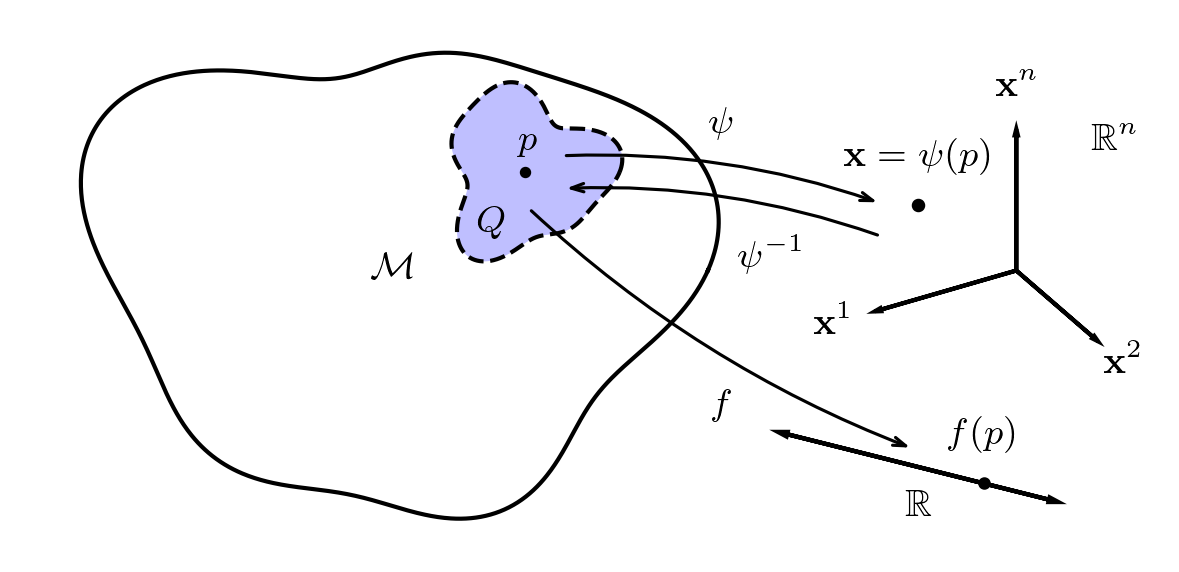

In [4]:
figname = r'..\images\manifoldtoscalar.pdf'


plt.figure(figsize=(4,2), dpi=300)
plt.gca().set_aspect('equal')

theta = np.linspace(0, 2*np.pi, 1000)
u, v = blob(theta, 4, 1.6)
plt.plot(u, v, 'k-', lw=1)

p = np.array([2,1.5])
plt.scatter(*p, color='k',s=3, zorder = 4)
plt.annotate(
    r"$p$",
    p + np.array([0,0.5]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

u,v = blob(theta, 1.2, 0,0, 0.2,0.1) + p.reshape(2,1)
plt.fill(
    u,v,
    facecolor ='b',
    edgecolor = None,
    alpha = 0.25)
plt.plot(u, v, 'k--', lw=1)

draw_axis(
    [9.5, 0],
    [
        r"$\mathbf{x}^1$",
        r"$\mathbf{x}^2$",
        r"$\mathbf{x}^n$"
    ],
    -150,
    30,
    2.5
)

R0 = np.array([6,-2.5])
RE = np.array([10,-3.5])
R1 = R0 - RE
R2 = RE - R0

fp_1 = R0 + 0.75 * R2 

plt.scatter(*fp_1, color='k', s=4)
plt.arrow(
    *R0,
    *R2,
    linewidth=1,
    head_width=0.075,
    head_length=0.15,
    color='k'
)

plt.arrow(
    *RE,
    *R1,
    linewidth=1,
    head_width=0.075,
    head_length=0.15,
    color='k'
)

RNpos = (RE + R0)/2 - np.array([0,0.6])
plt.annotate(
    r"$\mathbb{R}$",
    RNpos,
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$\mathbb{R}^n$",
    [11,2],
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

fp = np.array([8,1])
plt.scatter(
    fp[0],
    fp[1],
    color='k',
    s=5
)
plt.annotate(
    r"$\mathbf{x}=\psi(p)$",
    fp + np.array([0,0.75]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$\mathcal{M}$",
    [0,0],
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$Q$",
    p + np.array([-0.5,-0.75]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

arrow1 = FancyArrowPatch(
    p + np.array([0, -0.5]),
    (R0 + RE)/2 + np.array([0, 0.25]),
    connectionstyle="arc3,rad=0.1",
    arrowstyle='->,head_width=1,head_length=3',  # <-- Control head size
    color='k',
    linewidth=0.75
)
arrow2 = FancyArrowPatch(
    p + np.array([0.5, 0.25]),
    fp + np.array([-0.5, 0]),
    connectionstyle="arc3,rad=-0.1",
    arrowstyle='->,head_width=1,head_length=3',  # <-- Control head size
    color='k',
    linewidth=0.75
)

arrow3 = FancyArrowPatch(
    fp + np.array([-0.5, 0- 0.5]),
    p + np.array([0.5, 0.25 - 0.5]),
    connectionstyle="arc3,rad=0.1",
    arrowstyle='->,head_width=1,head_length=3',  # <-- Control head size
    color='k',
    linewidth=0.75
)

plt.annotate(
    r"$\psi$",
    p + (fp - p)/2 + np.array([0,1]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$\psi^{-1}$",
    p + (fp - p)/2 + np.array([0.75,-1]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)


plt.annotate(
    r"$f$",
    p + (RNpos - p)/2 + np.array([0,-1]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$f(p)$",
    fp_1 + np.array([0, 0.75]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)


plt.gca().add_patch(arrow1) 
plt.gca().add_patch(arrow2) 
plt.gca().add_patch(arrow3) 
# plt.xlim(-5,10)
plt.axis('off')
# plt.grid(False)
# plt.grid(zorder=0)
plt.tight_layout()   
plt.savefig(figname)
plt.show()


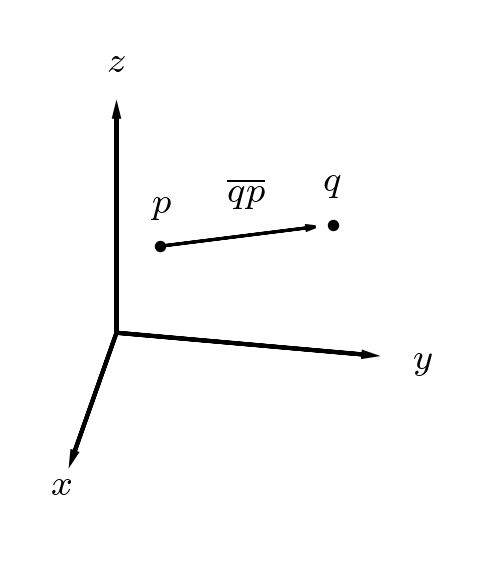

In [5]:

figname = r"..\images\R3vectors.pdf"

plt.figure(figsize = (4,2), dpi = 300)
plt.gca().set_aspect('equal')

draw_axis(
    [0,0],
    [
        r'$x$',
        r'$y$',
        r'$z$'
    ],
    -100,
    30,
    3,
    1.2
)

p = np.array([0.5,1])
q = np.array([2.5,1.25])

r = q - p 

plt.scatter(*p, color = 'k', s = 3)
plt.scatter(*q, color = 'k', s = 3)
plt.annotate(
    r"$p$",
    p + np.array([0, 0.5]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)
plt.annotate(
    r"$q$",
    q + np.array([0, 0.5]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)
plt.annotate(
    r"$\overline{qp}$",
    p + r/2 + np.array([0, 0.5]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)
plt.arrow(
    *p, *(r * 0.9), 
    linewidth=0.75,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True,
    color='k'
)
plt.axis('off')
plt.xlim(-1,4)
plt.ylim(-2.5,3.5)
plt.tight_layout()
plt.savefig(figname)
plt.show()




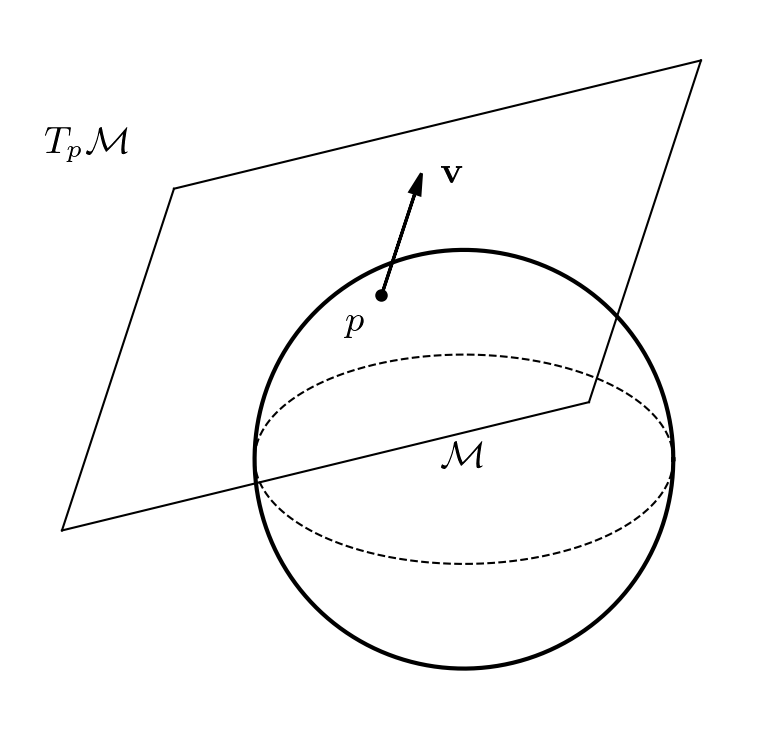

In [ ]:

figname = r"..\images\vectordef.pdf"

plt.figure(figsize=(4, 2.5), dpi=300)
plt.gca().set_aspect('equal')


# ============================================================
# Camera
# ============================================================

elevation = np.deg2rad(30)
azimuth   = np.deg2rad(40)


# Orthographic projection
P = np.array([
    [ np.cos(azimuth), np.sin(azimuth) * np.sin(elevation)],
    [-np.sin(azimuth), np.cos(azimuth) * np.sin(elevation)],
    [0, np.cos(elevation)]
])


# ============================================================
# Unit sphere
# ============================================================

theta = np.linspace(0, 2 * np.pi, 500)

radius = 1

sphere = np.array([
    np.cos(theta),
    np.sin(theta)
])

plt.plot(
    sphere[0],
    sphere[1],
    'k-',
    lw=1
)
# ============================================================
# Equator
# ============================================================

equator = np.array([
    np.cos(theta),
    np.sin(elevation) * np.sin(theta)
])

plt.plot(
    equator[0],
    equator[1],
    'k--',
    lw=0.5
)


# ============================================================
# Point p on the sphere
# ============================================================

p = np.array([1, 4, 2], dtype=float)

p /= np.linalg.norm(p)
p *= radius


# Project p
p2 = p @ P


# ============================================================
# Tangent-plane basis
# ============================================================

# Choose an arbitrary vector that is not parallel to p
a = np.array([0, 0, 1], dtype=float)


# First tangent vector
e1 = a - np.dot(a, p) * p
e1 /= np.linalg.norm(e1)


# Second tangent vector
e2 = np.cross(p, e1)
e2 /= np.linalg.norm(e2)


# ============================================================
# Tangent plane
#
# r(s,t) = p + s e1 + t e2
# ============================================================

s = np.linspace(-1.4, 1.4, 2)
t = np.linspace(-1.4, 1.4, 2)


# Draw plane lines in the e1 direction
for ti in t:

    r = (
        p[:, None]
        + e1[:, None] * s
        + e2[:, None] * ti
    )

    r2 = r.T @ P

    plt.plot(
        r2[:, 0],
        r2[:, 1],
        'k-',
        lw=0.5
    )


# Draw plane lines in the e2 direction
for si in s:

    r = (
        p[:, None]
        + e1[:, None] * si
        + e2[:, None] * t
    )

    r2 = r.T @ P

    plt.plot(
        r2[:, 0],
        r2[:, 1],
        'k-',
        lw=0.5
    )


# ============================================================
# Draw p
# ============================================================

plt.plot(
    p2[0],
    p2[1],
    'ko',
    ms=2
)


# ============================================================
# Draw tangent vectors
# ============================================================

scale = 1

e1_2 = e1 @ P
e2_2 = e2 @ P

plt.arrow(
    p2[0],
    p2[1],
    scale * e1_2[0],
    scale * e1_2[1],
    color='k',
    lw=0.75,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)

# plt.arrow(
#     p2[0],
#     p2[1],
#     scale * e2_2[0],
#     scale * e2_2[1],
#     color='k',
#     lw=1,
#     head_width=0.05,
#     head_length=0.1,
#     length_includes_head=True
# )


# # ============================================================
# # Draw normal vector p
# # ============================================================

# plt.arrow(
#     0,
#     0,
#     p2[0],
#     p2[1],
#     color='k',
#     lw=1,
#     head_width=0.05,
#     head_length=0.1,
#     length_includes_head=True
# )


# ============================================================
# Labels
# ============================================================

plt.annotate(
    r'$p$',
    (
        1.1 * p2[0] - 0.1,
        1.1 * p2[1] - 0.2
    ),
    ha='center',
    va='center'
)

plt.annotate(
    r'$\mathbf{v}_p$',
    (
        p2[0] + 1.0 * scale * e1_2[0] + 0.15,
        p2[1] + 1.0 * scale * e1_2[1]
    ),
    ha='center',
    va='center'
)

plt.annotate(
    r'$T_p \mathcal{M}$',
    (
        -1.8,
        1.5
    ),
    ha='center',
    va='center'
)

plt.annotate(
    r'$\mathcal{M}$',
    [0,0],
    ha='center',
    va='center'
)

# plt.annotate(
#     r'$\mathbf{e}_2$',
#     (
#         p2[0] + 1.0 * scale * e2_2[0],
#         p2[1] + 1.0 * scale * e2_2[1]
#     )
# )


# ============================================================
# Formatting
# ============================================================

plt.axis('off')
plt.tight_layout()
plt.savefig(figname)
plt.show()

Projection dynamics

Say I have a point $x,y,z$, and I have a camera which can rotate azimuth and elevate. 

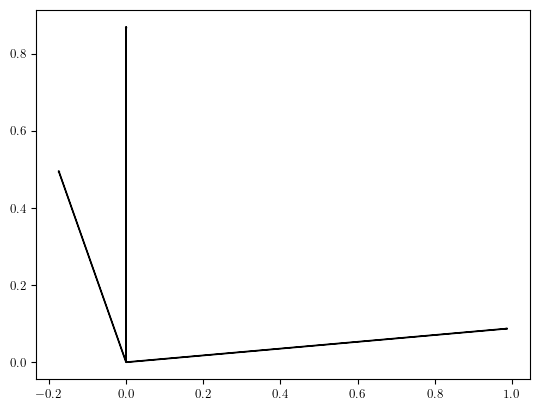

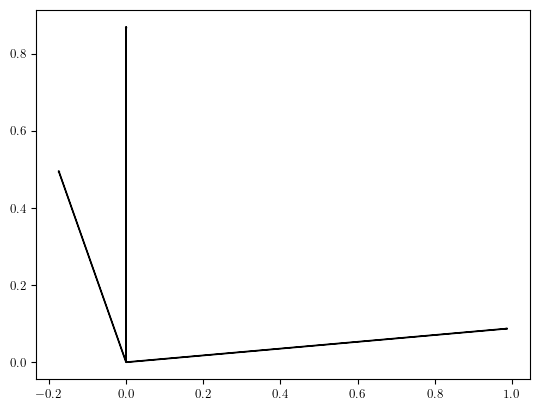

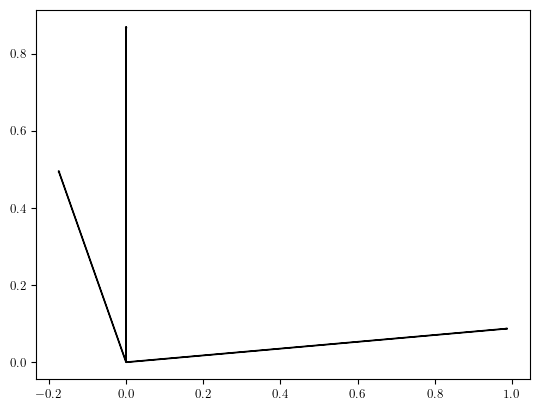

In [7]:
plt.figure()
plt.gca().set_aspect('equal')

axes3d = np.array(
    [
        [1,0,0],
        [0,1,0],
        [0,0,1]
    ]
)

x = axes3d[0]
y = axes3d[1]
z = axes3d[2]

origin = np.array([0,0,0])


xarrow = x - origin
yarrow = y - origin 
zarrow = z - origin 

azimuth = np.deg2rad(10)
elevation = np.deg2rad(30)

azimuth_transform = np.array([
    [np.cos(azimuth), -np.sin(azimuth), 0],
    [np.sin(azimuth),  np.cos(azimuth), 0],
    [0, 0, 1]
])

elevate_transform = np.array([
    [1, 0, 0],
    [0, np.cos(elevation), -np.sin(elevation)],
    [0, np.sin(elevation),  np.cos(elevation)],
])

xp = elevate_transform @ azimuth_transform @ xarrow
yp = elevate_transform @ azimuth_transform @ yarrow 
zp = elevate_transform @ azimuth_transform @ zarrow

op = origin[[0,2]]
xp = xp[[0,2]]
yp = yp[[0,2]]
zp = zp[[0,2]]

plt.arrow(
    *op,
    *xp
)
plt.arrow(
    *op,
    *yp
)
plt.arrow(
    *op,
    *zp
)
plt.show()

plt.figure()
plt.gca().set_aspect('equal')

projection_transform = np.array([
    [ np.cos(azimuth), -np.sin(azimuth), 0],
    [ np.sin(elevation) * np.sin(azimuth),  
      np.sin(elevation) * np.cos(azimuth),   
      np.cos(elevation) ]                   
])

op = projection_transform @ origin
xp = projection_transform @ xarrow
yp = projection_transform @ yarrow 
zp = projection_transform @ zarrow

plt.arrow(
    *op,
    *xp
)
plt.arrow(
    *op,
    *yp
)
plt.arrow(
    *op,
    *zp
)

plt.show()


def project2d(
    vector, 
    azimuth,
    elevation,
    roll=0,
    perspective=False,
    focal_length=1,
    camera_distance=5  # Distance from camera to origin
):
    azimuth_transform = np.array([
        [np.cos(azimuth), -np.sin(azimuth), 0],
        [np.sin(azimuth),  np.cos(azimuth), 0],
        [0, 0, 1]
    ])

    elevate_transform = np.array([
        [1, 0, 0],
        [0, np.cos(elevation), -np.sin(elevation)],
        [0, np.sin(elevation),  np.cos(elevation)],
    ])

    roll_transform = np.array([
        [np.cos(roll), 0, -np.sin(roll)],
        [0, 1, 0],
        [np.sin(roll), 0,  np.cos(roll)]
    ])

    rotation_matrix = roll_transform @ elevate_transform @ azimuth_transform
    vector_rotated = rotation_matrix @ vector

    ydrop = np.array([
        [1, 0, 0],
        [0, 0, 1]
    ])

    projection = ydrop @ vector_rotated
    if perspective:
        # Add camera distance offset to depth
        depth = vector_rotated[1] + camera_distance
        return focal_length * projection / depth
    else:
        return projection


plt.figure()
plt.gca().set_aspect('equal')
op = project2d(origin, azimuth, elevation)
xp = project2d(xarrow, azimuth, elevation)
yp = project2d(yarrow, azimuth, elevation)
zp = project2d(zarrow, azimuth, elevation)

plt.arrow(
    *op,
    *xp
)
plt.arrow(
    *op,
    *yp
)
plt.arrow(
    *op,
    *zp
)
plt.show()


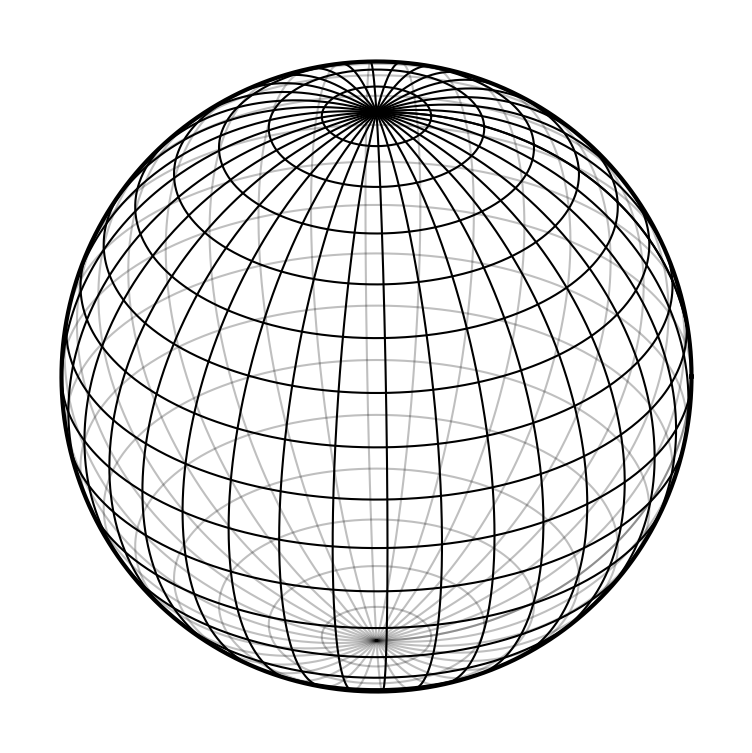

In [8]:
dth = 10
theta = np.deg2rad(np.arange(0, 360 + dth, dth))
phi = np.deg2rad(np.arange(0, 180 + dth, dth))
radius = 1

azimuth = np.deg2rad(2)
elevation = np.deg2rad(33)

# 3D rotation matrix
rotation_3d = np.array([
    [1, 0, 0],
    [0, np.cos(elevation), -np.sin(elevation)],
    [0, np.sin(elevation),  np.cos(elevation)]
]) @ np.array([
    [np.cos(azimuth), -np.sin(azimuth), 0],
    [np.sin(azimuth),  np.cos(azimuth), 0],
    [0, 0, 1]
]) 

# Projection matrix (drop y after rotation)
projection_transform = np.array([
    [1, 0, 0],
    [0, 0, 1]
]) @ rotation_3d

plt.figure(figsize=(3, 3), dpi=300)
plt.gca().set_aspect('equal')

# Latitude lines
theta_smooth = np.deg2rad(np.linspace(0, 360, 720))
for lat in phi:
    x = radius * np.cos(theta_smooth) * np.sin(lat)
    y = radius * np.sin(theta_smooth) * np.sin(lat)
    z = radius * np.cos(lat) * np.ones_like(theta_smooth)

    points = np.array([x, y, z])
    
    rotated = rotation_3d @ points
    projected = projection_transform @ points
    
    u = projected[0].copy()
    v = projected[1].copy()
    
    y_rot = rotated[1]
    
    # FRONT-FACING PLOT (y_rot < 0): set back-facing to NaN
    u_front = u.copy()
    v_front = v.copy()
    u_front[y_rot >= 0] = np.nan
    v_front[y_rot >= 0] = np.nan
    plt.plot(u_front, v_front, 'k-', lw=0.5, alpha=1.0)
    
    # BACK-FACING PLOT (y_rot >= 0): set front-facing to NaN
    u_back = u.copy()
    v_back = v.copy()
    u_back[y_rot < 0] = np.nan
    v_back[y_rot < 0] = np.nan
    plt.plot(u_back, v_back, 'k-', lw=0.5, alpha=0.25)

# Longitude lines
phi_smooth = np.deg2rad(np.linspace(0, 180, 720))
for lng in theta:
    x = radius * np.cos(lng) * np.sin(phi_smooth)
    y = radius * np.sin(lng) * np.sin(phi_smooth)
    z = radius * np.cos(phi_smooth)

    points = np.array([x, y, z])
    
    rotated = rotation_3d @ points
    projected = projection_transform @ points
    
    u = projected[0].copy()
    v = projected[1].copy()
    
    y_rot = rotated[1]
    
    # FRONT-FACING PLOT (y_rot < 0): set back-facing to NaN
    u_front = u.copy()
    v_front = v.copy()
    u_front[y_rot >= 0] = np.nan
    v_front[y_rot >= 0] = np.nan
    plt.plot(u_front, v_front, 'k-', lw=0.5, alpha=1.0)
    
    # BACK-FACING PLOT (y_rot >= 0): set front-facing to NaN
    u_back = u.copy()
    v_back = v.copy()
    u_back[y_rot < 0] = np.nan
    v_back[y_rot < 0] = np.nan
    plt.plot(u_back, v_back, 'k-', lw=0.5, alpha=0.25)

# Equator circle
circle = radius * np.array([np.cos(theta_smooth), np.sin(theta_smooth)])
plt.plot(*circle, 'k-', lw=1, alpha=1.0)

plt.axis(False)
plt.savefig(r"..\images\sphere.pdf")
plt.show()
    

IndexError: arrays used as indices must be of integer (or boolean) type

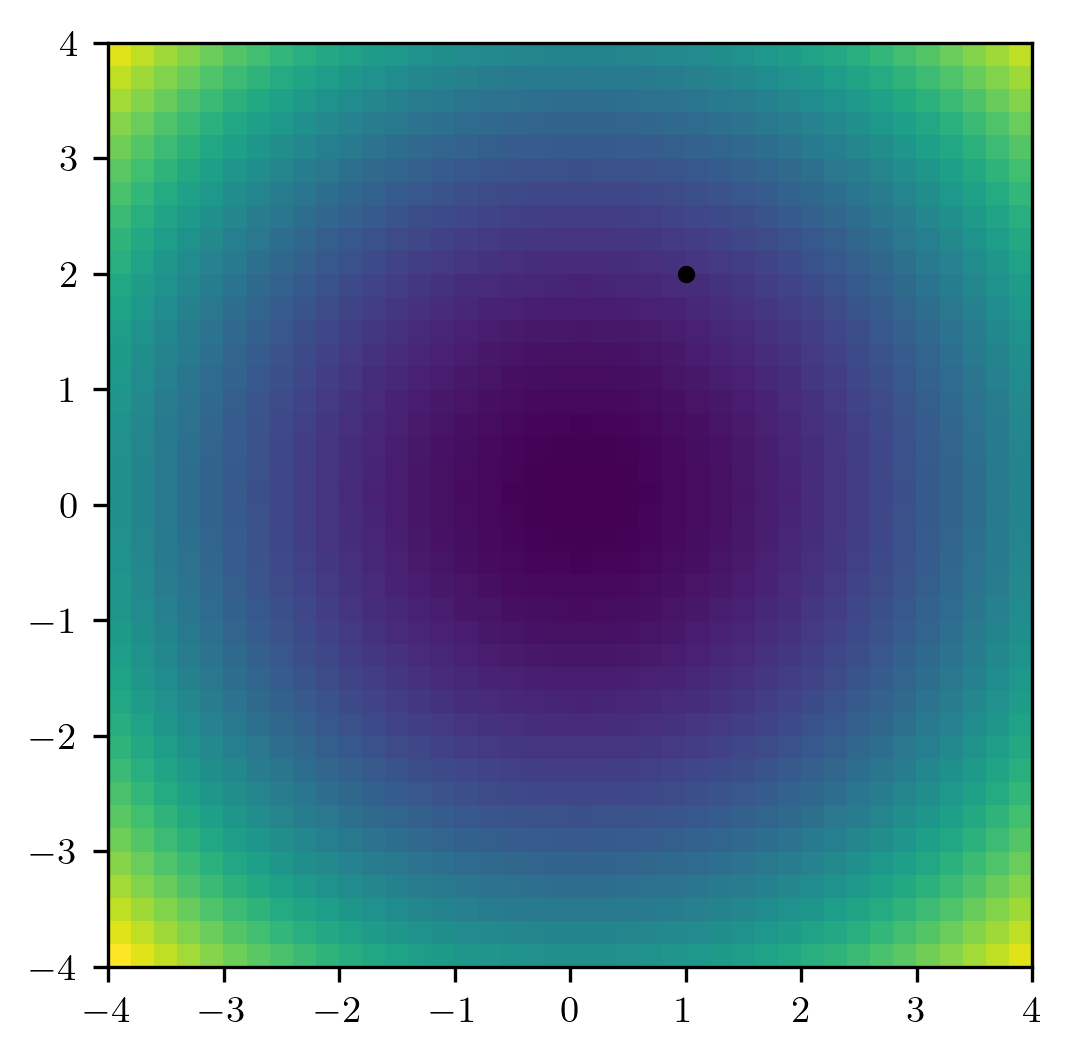

In [29]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(4,4), dpi=300)
plt.gca().set_aspect('equal')

lims = (-4,4)
dx = 0.2

x = np.arange(*lims, dx)
y = np.arange(*lims, dx)

xv, yv = np.meshgrid(x, y)
rv = np.sqrt((xv**2) + (yv**2))
th = np.atan2(yv,xv)
X = np.array([xv, yv])
R = np.array([rv, th])

def f(X):
    return X[0]**2 + X[1]**2


Z = f(X)

plt.imshow(
    Z,
    extent=[*lims, *lims],
    origin='lower',
    cmap='viridis'
)

p = np.array([1., 2.])

plt.scatter(
    *p,
    s=10,
    color='k'
)

vxmu = np.array([1.0, 0.0])
vymu = np.array([0.0,0.0])

def partial(p, X, mu, h=dx):

    def Xp(pt):
        ix = np.argmin(np.abs(X[0][0, :] - pt[0]))
        iy = np.argmin(np.abs(X[1][:, 0] - pt[1]))
        return X[:, iy, ix]

    p_plus = p.copy()
    p_minus = p.copy()

    p_plus[mu] += h
    p_minus[mu] -= h

    return (Xp(p_plus) - Xp(p_minus)) / (2*h)

vxp_f = np.zeros_like(vxmu)
vyp_f = np.zeros_like(vymu)

for mu in range(len(vxmu)):
    vxp_f += vxmu[mu] * partial(p, f, X, mu)
    vyp_f += vymu[mu] * partial(p, f, X, mu)
print(vxp_f)

plt.arrow(
    *p,
    *vxp_f,
    color='k',
    lw=0.75,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)
plt.arrow(
    *p,
    *vyp_f,
    color='k',
    lw=0.75,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)
plt.xlim(lims)
plt.ylim(lims)
plt.show()

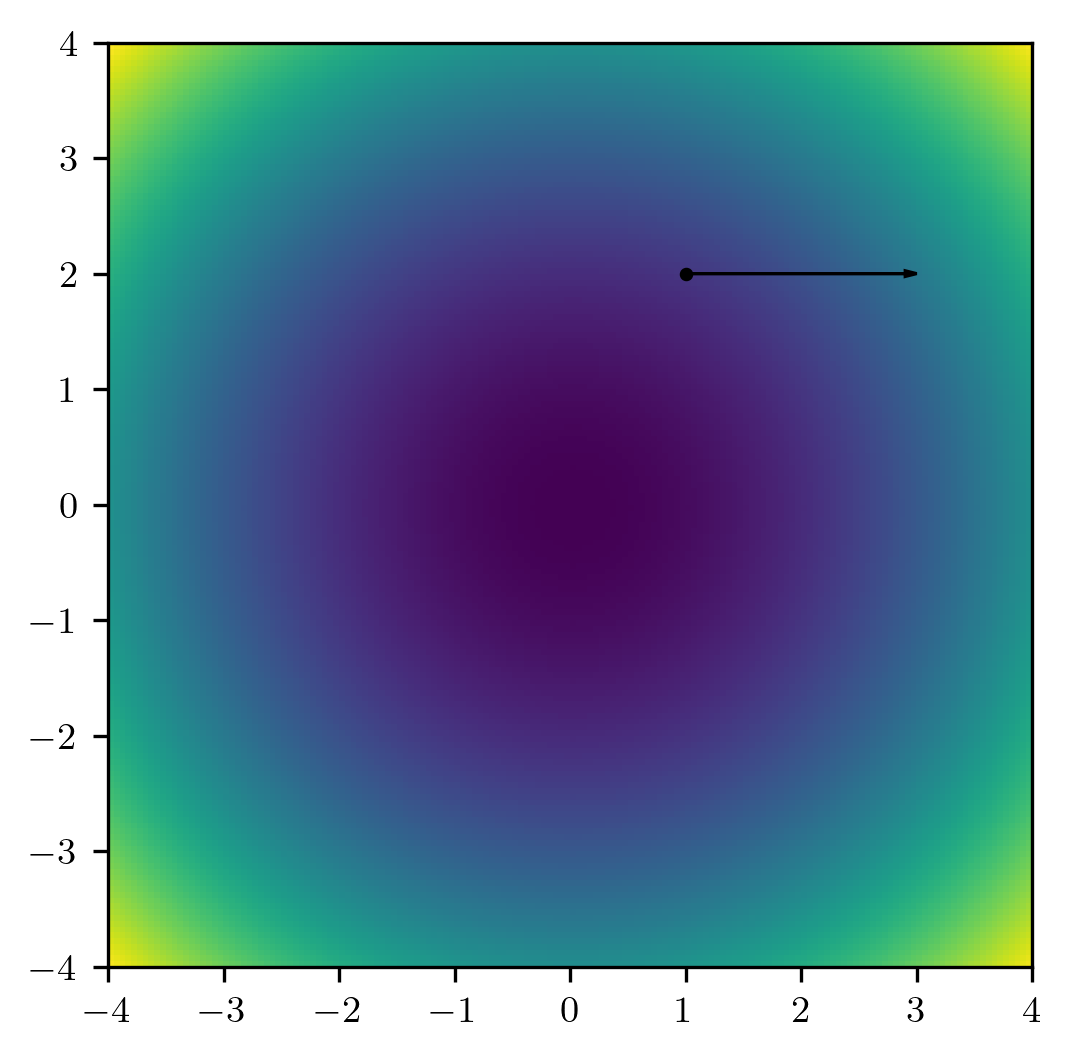

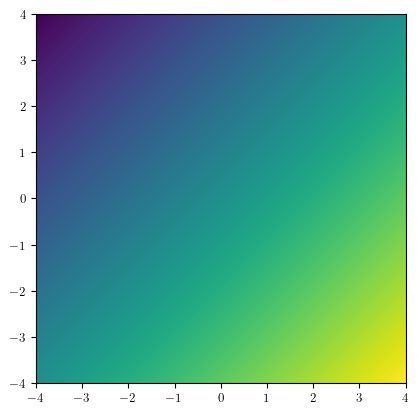

In [ ]:
plt.figure(figsize=(4,4), dpi=300)
plt.gca().set_aspect('equal')

lims = (-4,4)
dx = 0.05

x = np.arange(*lims, dx)
y = np.arange(*lims, dx)

xv, yv = np.meshgrid(x, y)
rv = np.sqrt((xv**2) + (yv**2))
th = np.atan2(yv,xv)
X = np.array([xv, yv])
R = np.array([rv, th])

Z = X[0]**2 + X[1]**2 

p = np.array([1,2])

plt.scatter(*p, s= 5, color = 'k')
plt.imshow(Z, extent = [*lims, *lims], cmap = 'viridis')


vx = np.array([1,0])
vy = np.array([0,1])

def partial_cart(p,mu):
    return 2 * p[mu]


vpx = np.zeros_like(vx)
for mu in range(len(vpx)):
    vpx[mu] += vx[mu] * partial_cart(p, mu)


plt.arrow(
    *p,
    *vpx,
    color='k',
    lw=0.75,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)
plt.show()

Z = 2*xv + 2*yv 
plt.imshow(Z, extent =[*lims, *lims])
